# Statistical Models

In this notebook, I apply statistical forecasting models to the cleaned sales time series from Week 1.
The goal is to train statistical models on data from **2013-01-01 to 2013-12-31** and evaluate their forecasts on data from **2014-01-01 to 2014-03-31**.

# 1. Environment Setup

In [3]:
# pandas - for working with tabular data
import pandas as pd

# numpy - for numerical operations
import numpy as np

# matplotlib - for plotting charts
import matplotlib.pyplot as plt

# seaborn - for improved chart styling
import seaborn as sns

# statsmodels - for time series analysis and forecasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# scikit-learn - for evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score

# warnings - to hide unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Data Loading

In [4]:
# Load the cleaned main time series from Week 1
timeseries = pd.read_csv("../../data/timeseries_cleaned.csv")

In [5]:
# Display the first rows of the cleaned time series
timeseries.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [6]:
timeseries.shape

(452, 2)

# 3. Data Preparation and Exploration

In [7]:
# Check basic information about the cleaned time series
timeseries.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    str    
 1   unit_sales  452 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB


In [8]:
# Convert the date column to datetime format
timeseries["date"] = pd.to_datetime(timeseries["date"])

In [9]:
# Check data types after datetime conversion
print(timeseries.dtypes)

date          datetime64[us]
unit_sales           float64
dtype: object


In [10]:
# Check the date range of the cleaned time series
print("Date range:", timeseries["date"].min(), "to", timeseries["date"].max())

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00


In [11]:
# Set the date column as the index for time series modeling
timeseries = timeseries.set_index("date")

timeseries.head()

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


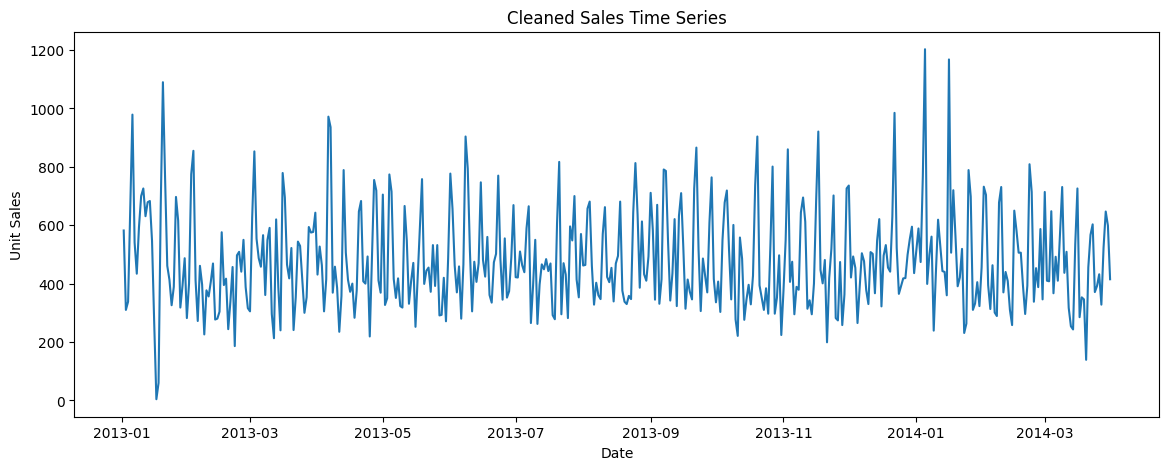

In [12]:
# Plot the cleaned sales time series
plt.figure(figsize=(14, 5))
plt.plot(timeseries.index, timeseries["unit_sales"])
plt.title("Cleaned Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

# 4. Time Series Decomposition

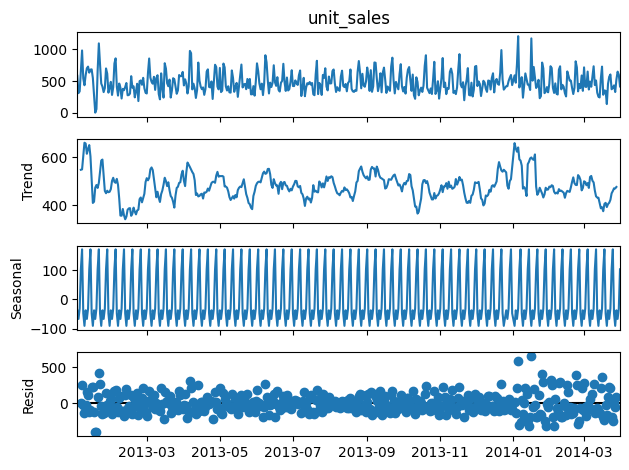

In [13]:
# Decompose the time series into trend, seasonality, and residuals
decomposition = seasonal_decompose(timeseries["unit_sales"], model="additive", period=7)

# Plot the decomposition components
decomposition.plot()
plt.show()

# 5. Stationarity Check

In [14]:
# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -5.092260058040776
p-value: 1.453017741687818e-05
Critical Values:
   1%: -3.445542818501549
   5%: -2.868238133603207
   10%: -2.5703378690483176


The ADF test suggests that the time series is likely stationary, because the p-value is below 0.05. This means we can proceed with statistical modeling without applying an additional differencing step at this stage.

# 6. Autocorrelation Analysis

<Figure size 1000x400 with 0 Axes>

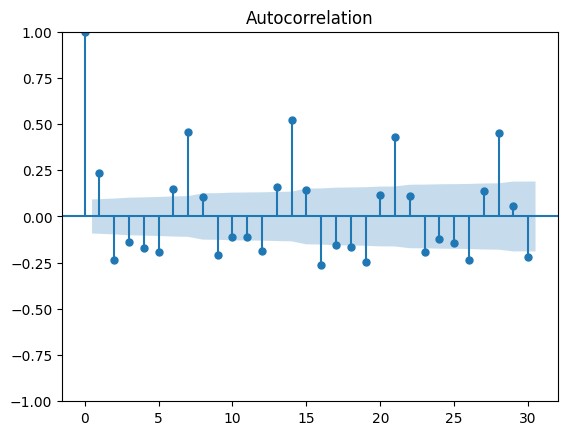

In [15]:
# Plot the autocorrelation function (ACF)
plt.figure(figsize=(10, 4))
plot_acf(timeseries["unit_sales"], lags=30)
plt.show()

<Figure size 1000x400 with 0 Axes>

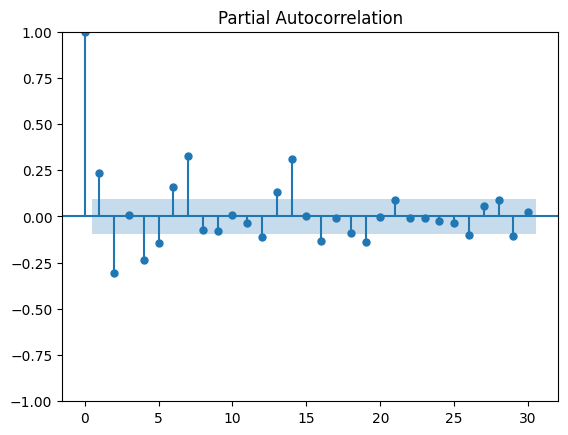

In [16]:
# Plot the partial autocorrelation function (PACF)
plt.figure(figsize=(10, 4))
plot_pacf(timeseries["unit_sales"], lags=30)
plt.show()

The ACF and PACF plots show several significant spikes, including a visible repeating weekly pattern. This suggests that autoregressive and seasonal components may be useful in the statistical forecasting models.

# 7. Train-Test Split

In [17]:
# Split the time series into train and test sets using the official project periods
train = timeseries.loc["2013-01-01":"2013-12-31"].copy()
test = timeseries.loc["2014-01-01":"2014-03-31"].copy()

In [18]:
# Check the shape and date range of the train and test sets
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Train shape: (363, 1)
Test shape: (89, 1)
Train period: 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test period: 2014-01-02 00:00:00 to 2014-03-31 00:00:00


# 8. First Statistical Model

In this section, I train the first statistical forecasting model using the training period and evaluate its predictions on the test period.

In [19]:
# Train the first SARIMAX model
model_1 = SARIMAX(
    train["unit_sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7)
)

model_1_fit = model_1.fit(disp=False)

In [20]:
# Display the summary of the fitted SARIMAX model
print(model_1_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  363
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2251.336
Date:                           Mon, 20 Apr 2026   AIC                           4512.673
Time:                                   17:51:30   BIC                           4532.145
Sample:                                        0   HQIC                          4520.413
                                           - 363                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.004    244.012      0.000       0.992       1.008
ma.L1         -0.9966      0.034    -28.958

In [21]:
# Generate predictions for the test period
forecast_1 = model_1_fit.predict(
    start=test.index[0],
    end=test.index[-1]
)

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

In [22]:
# Generate out-of-sample forecasts for the full test period
forecast_1 = model_1_fit.forecast(steps=len(test))